### All important Libraries

In [1]:
import torch
import torchvision
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

### Data Preprocessing

In [2]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

### file zip extractor

In [3]:
import zipfile
import os

zip_path = "/content/AI-ML Pre-Main.zip"
extract_path = "Distracted_Driver"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP file successfully extracted.")

ZIP file successfully extracted.


### Loading the  Dataset

In [4]:
import torchvision.datasets as datasets
from torchvision import transforms
from torch.utils.data import DataLoader


In [5]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])


In [6]:
import zipfile

zip_path = "/content/Distracted_Driver/Distracted Drivers/train_0.zip"
extract_path = "/content/Distracted_Driver/Distracted Drivers/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [7]:
zip_path = "/content/Distracted_Driver/Distracted Drivers/train_1.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

### Distraction Visualisation

In [10]:
from torchvision import datasets, transforms

transform = transforms.ToTensor()

dataset = datasets.ImageFolder(
    root="/content/Distracted_Driver/Distracted Drivers/train",
    transform=transform
)

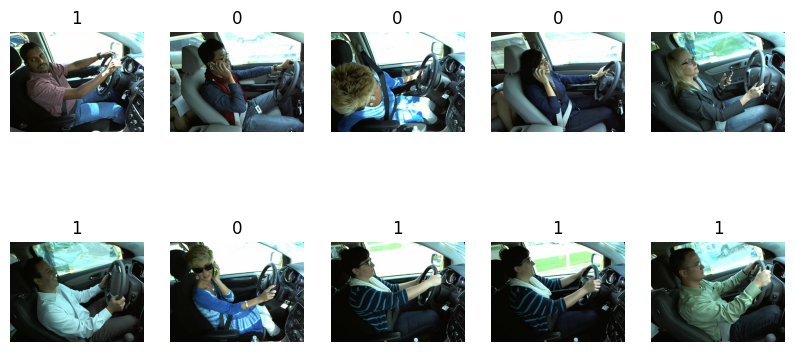

In [12]:
import random
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,5, figsize=(10,5))

indices = random.sample(range(len(dataset)), 10)

for ax, idx in zip(axes.flat, indices):

    img, label = dataset[idx]

    ax.imshow(img.permute(1,2,0))
    ax.set_title(label)
    ax.axis("off")

plt.show()

### Class imbalance

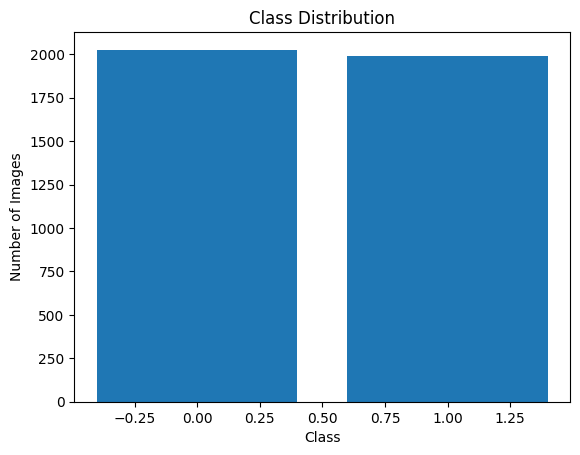

In [13]:
import matplotlib.pyplot as plt
from collections import Counter

labels = dataset.targets
count = Counter(labels)

plt.bar(count.keys(), count.values())
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution")

plt.show()

### My Dataset

In [14]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root="/content/Distracted_Driver/Distracted Drivers/train",
    transform=transform
)

print(dataset.classes)

['0', '1']


#### Train test Splitting

In [15]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [16]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=32)

In [17]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

### Model Loading

In [18]:
import torchvision.models as models
import torch.nn as nn

model = models.mobilenet_v3_small(pretrained=True)

model.classifier[3] = nn.Linear(
    model.classifier[3].in_features,
    2
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 113MB/s]


In [19]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#### Fitting and Training

In [20]:
import torch

epochs = 5

for epoch in range(epochs):

    model.train()

    for images, labels in train_loader:

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch:", epoch+1, "Loss:", loss.item())

Epoch: 1 Loss: 0.02736137993633747
Epoch: 2 Loss: 0.3820848762989044
Epoch: 3 Loss: 0.0024010043125599623
Epoch: 4 Loss: 0.00044884043745696545
Epoch: 5 Loss: 0.0013816967839375138


In [21]:
import torch

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

### Evaluation on validation

In [22]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(all_labels, all_preds)

print("Accuracy:", accuracy)

Accuracy: 0.9900373599003736


### Accuarcy matrics on Validation

In [23]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       398
           1       0.99      0.99      0.99       405

    accuracy                           0.99       803
   macro avg       0.99      0.99      0.99       803
weighted avg       0.99      0.99      0.99       803



#### Confusion Matrix

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

print(cm)

[[394   4]
 [  4 401]]


Confusion Visualisation

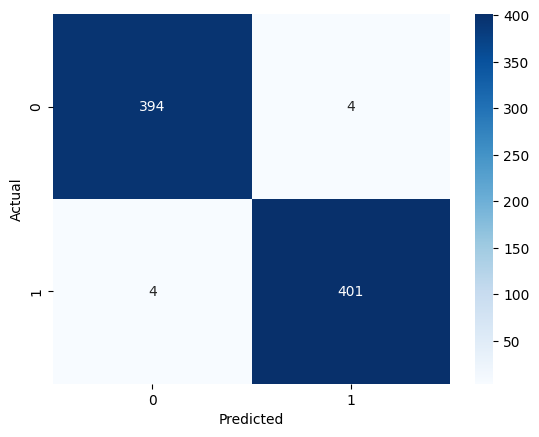

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Evaluation on Test Data

In [26]:
import zipfile

zip_path = "/content/Distracted_Driver/Distracted Drivers/test.zip"
extract_path = "/content/Distracted_Driver/Distracted Drivers/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Test dataset extracted successfully")

Test dataset extracted successfully


In [27]:
import os
from PIL import Image

test_path = "/content/Distracted_Driver/Distracted Drivers/test"

test_images = os.listdir(test_path)

print(len(test_images))

1401


In [28]:
import os
from PIL import Image
import torch

test_path = "/content/Distracted_Driver/Distracted Drivers/test"

model.eval()

predictions = []

for img_name in os.listdir(test_path):

    if img_name.endswith((".jpg",".png",".jpeg")):   # image filter

        img_path = os.path.join(test_path, img_name)

        img = Image.open(img_path).convert("RGB")

        img = transform(img).unsqueeze(0)

        with torch.no_grad():

            output = model(img)

            _, pred = torch.max(output,1)

            predictions.append(pred.item())

print("Total Predictions:", len(predictions))

Total Predictions: 1400


In [29]:
import pandas as pd

labels_df = pd.read_csv("/content/Distracted_Driver/Distracted Drivers/train_labels.csv")

print(labels_df.head())

            file  label
0  img_44733.jpg    1.0
1  img_72999.jpg    1.0
2  img_25094.jpg    1.0
3  img_69092.jpg    1.0
4  img_92629.jpg    1.0


In [30]:
import os
import pandas as pd
from PIL import Image
import torch

test_path = "/content/Distracted_Driver/Distracted Drivers/test"

model.eval()

image_ids = []
predictions = []

for img_name in os.listdir(test_path):

    if img_name.endswith((".jpg",".jpeg",".png")):

        img_path = os.path.join(test_path, img_name)

        img = Image.open(img_path).convert("RGB")

        img = transform(img).unsqueeze(0)

        with torch.no_grad():

            output = model(img)

            _, pred = torch.max(output,1)


        image_ids.append(img_name.split(".")[0])

        predictions.append(pred.item())


submission = pd.DataFrame({
    "img": image_ids,
    "label": predictions
})

submission.to_csv("test_predictions.csv", index=False)

print("CSV file created successfully")

CSV file created successfully
